In [ ]:
!pip -q install datasets transformers seqeval accelerate evaluate

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.8 MB/s eta 0:00:00


In [ ]:
# Loading and inspecting the SNIPS joint intent-slot dataset

from datasets import load_dataset

dataset = load_dataset("bkonkle/snips-joint-intent")

print(dataset)
print("\nTrain columns:", dataset["train"].column_names)
print("Test columns:", dataset["test"].column_names)

print("\nFirst training example:")
print(dataset["train"][0])

print("\nFirst test example:")
print(dataset["test"][0])

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

train.csv:   0%|          | 0.00/1.74M [00:00<?, ?B/s]

test.csv:   0%|          | 0.00/93.3k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/13084 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/700 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 13084
    })
    test: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 700
    })
})

Train columns: ['input', 'intent', 'slots']
Test columns: ['input', 'intent', 'slots']

First training example:
{'input': 'listen to westbam alumb allergic on google music', 'intent': 'PlayMusic', 'slots': 'O O B-artist O B-album O B-service I-service'}

First test example:
{'input': 'add sabrina salerno to the grime instrumentals playlist', 'intent': 'AddToPlaylist', 'slots': 'O B-artist I-artist O O B-playlist I-playlist O'}


In [ ]:
# Preparing labels and checking word-slot alignment

from datasets import DatasetDict

# Creating a validation split from training data
split_dataset = dataset["train"].train_test_split(test_size=0.1, seed=42)

data = DatasetDict({
    "train": split_dataset["train"],
    "validation": split_dataset["test"],
    "test": dataset["test"]
})

intent_labels = sorted(set(data["train"]["intent"]) | set(data["validation"]["intent"]) | set(data["test"]["intent"]))
intent2id = {label: i for i, label in enumerate(intent_labels)}
id2intent = {i: label for label, i in intent2id.items()}

slot_label_set = set()

for split in ["train", "validation", "test"]:
    for slot_string in data[split]["slots"]:
        slot_label_set.update(slot_string.split())

slot_labels = sorted(slot_label_set)
slot2id = {label: i for i, label in enumerate(slot_labels)}
id2slot = {i: label for label, i in slot2id.items()}

print("Dataset splits:")
print(data)

print("\nNumber of intent labels:", len(intent_labels))
print(intent_labels)

print("\nNumber of slot labels:", len(slot_labels))
print(slot_labels)

# Checking that number of words matches number of slot tags
def check_alignment(example):
    words = example["input"].split()
    slots = example["slots"].split()
    return len(words) == len(slots)

for split in ["train", "validation", "test"]:
    total = len(data[split])
    correct = sum(check_alignment(ex) for ex in data[split])
    print(f"{split}: {correct}/{total} examples have matching word-slot lengths")

# one processed example
ex = data["train"][0]
print("\nExample input:", ex["input"])
print("Words:", ex["input"].split())
print("Intent:", ex["intent"], "->", intent2id[ex["intent"]])
print("Slots:", ex["slots"].split())
print("Slot IDs:", [slot2id[s] for s in ex["slots"].split()])

Dataset splits:
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 11775
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 700
    })
})

Number of intent labels: 7
['AddToPlaylist', 'BookRestaurant', 'GetWeather', 'PlayMusic', 'RateBook', 'SearchCreativeWork', 'SearchScreeningEvent']

Number of slot labels: 72
['B-album', 'B-artist', 'B-best_rating', 'B-city', 'B-condition_description', 'B-condition_temperature', 'B-country', 'B-cuisine', 'B-current_location', 'B-entity_name', 'B-facility', 'B-genre', 'B-geographic_poi', 'B-location_name', 'B-movie_name', 'B-movie_type', 'B-music_item', 'B-object_location_type', 'B-object_name', 'B-object_part_of_series_type', 'B-object_select', 'B-object_type', 'B-party_size_description', 'B-party_size_number', 'B-playlist', 'B-playlist_owner', 'B-poi', 'B-

In [ ]:
# Tokenisation and slot-label alignment for DistilBERT

from transformers import AutoTokenizer

MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# Filtering out the one example where word count != slot count
def is_aligned(example):
    return len(example["input"].split()) == len(example["slots"].split())

data = data.filter(is_aligned)

print("After filtering:")
print(data)

MAX_LENGTH = 64
IGNORE_INDEX = -100

def tokenize_and_align_labels(example):
    words = example["input"].split()
    slot_tags = example["slots"].split()

    tokenized = tokenizer(
        words,
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

    word_ids = tokenized.word_ids()

    aligned_slot_ids = []
    previous_word_id = None

    for word_id in word_ids:
        if word_id is None:
            aligned_slot_ids.append(IGNORE_INDEX)
        elif word_id != previous_word_id:
            aligned_slot_ids.append(slot2id[slot_tags[word_id]])
        else:
            aligned_slot_ids.append(IGNORE_INDEX)
        previous_word_id = word_id

    tokenized["intent_label"] = intent2id[example["intent"]]
    tokenized["slot_labels"] = aligned_slot_ids
    tokenized["words"] = words
    tokenized["slot_tags"] = slot_tags

    return tokenized

encoded_data = data.map(tokenize_and_align_labels)

columns_to_keep = ["input_ids", "attention_mask", "intent_label", "slot_labels"]
encoded_data.set_format(type="torch", columns=columns_to_keep)

print("\nEncoded dataset:")
print(encoded_data)

sample = tokenize_and_align_labels(data["train"][0])
tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])

print("\nOriginal sentence:", data["train"][0]["input"])
print("Original slots:", data["train"][0]["slots"])
print("\nTokenised output:")
for tok, lab_id in zip(tokens, sample["slot_labels"]):
    label = "IGN" if lab_id == IGNORE_INDEX else id2slot[lab_id]
    print(f"{tok:15s} -> {label}")

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Filter:   0%|          | 0/11775 [00:00<?, ? examples/s]

...

After filtering:
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 11774
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots'],
        num_rows: 700
    })
})


Map:   0%|          | 0/11774 [00:00<?, ? examples/s]

Map:   0%|          | 0/1309 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]


Encoded dataset:
DatasetDict({
    train: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 11774
    })
    validation: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 1309
    })
    test: Dataset({
        features: ['input', 'intent', 'slots', 'input_ids', 'token_type_ids', 'attention_mask', 'intent_label', 'slot_labels', 'words', 'slot_tags'],
        num_rows: 700
    })
})

Original sentence: table for 6 at a brasserie
Original slots: O O B-party_size_number O O B-restaurant_type

Tokenised output:
[CLS]           -> IGN
table           -> O
for             -> O
6               -> B-party_size_number
at              -> O
a               -> O
brass           -> B-restaurant_type
##erie          -> IGN
[SEP]           -> IGN
[

In [ ]:
# Defining a joint DistilBERT model for intent classification and slot filling

import torch
import torch.nn as nn
from transformers import AutoModel

class JointIntentSlotDistilBERT(nn.Module):
    def __init__(self, model_name, num_intents, num_slots, dropout_rate=0.2):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        hidden_size = self.bert.config.hidden_size

        self.dropout = nn.Dropout(dropout_rate)

        self.intent_classifier = nn.Linear(hidden_size, num_intents)

        self.slot_classifier = nn.Linear(hidden_size, num_slots)

        self.intent_loss_fn = nn.CrossEntropyLoss()
        self.slot_loss_fn = nn.CrossEntropyLoss(ignore_index=IGNORE_INDEX)

    def forward(self, input_ids, attention_mask, intent_label=None, slot_labels=None):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        sequence_output = self.dropout(outputs.last_hidden_state)

        cls_output = sequence_output[:, 0, :]

        intent_logits = self.intent_classifier(cls_output)
        slot_logits = self.slot_classifier(sequence_output)

        loss = None

        if intent_label is not None and slot_labels is not None:
            intent_loss = self.intent_loss_fn(intent_logits, intent_label)

            # slot_logits: [batch, seq_len, num_slots]
            # slot_labels: [batch, seq_len]
            slot_loss = self.slot_loss_fn(
                slot_logits.view(-1, slot_logits.shape[-1]),
                slot_labels.view(-1)
            )

            loss = intent_loss + slot_loss

        return {
            "loss": loss,
            "intent_logits": intent_logits,
            "slot_logits": slot_logits
        }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = JointIntentSlotDistilBERT(
    model_name=MODEL_NAME,
    num_intents=len(intent_labels),
    num_slots=len(slot_labels)
).to(device)

print("Model created successfully.")
print("Number of intents:", len(intent_labels))
print("Number of slot labels:", len(slot_labels))

Using device: cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model created successfully.
Number of intents: 7
Number of slot labels: 72


In [ ]:
import datasets
import datasets.config

datasets.config.TORCHVISION_AVAILABLE = False

encoded_data.reset_format()

columns_to_keep = ["input_ids", "attention_mask", "intent_label", "slot_labels"]
encoded_data.set_format(type="torch", columns=columns_to_keep)

print("Torchvision disabled inside datasets.")
print("Dataset format reset successfully.")
print("Device:", device)

Torchvision disabled inside datasets.
Dataset format reset successfully.
Device: cuda


In [ ]:
# Trainung the clean joint intent-slot model

from torch.utils.data import DataLoader
from torch.optim import AdamW
from tqdm.auto import tqdm
import numpy as np
import random

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

BATCH_SIZE = 32
EPOCHS = 3
LEARNING_RATE = 3e-5

train_loader = DataLoader(encoded_data["train"], batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(encoded_data["validation"], batch_size=BATCH_SIZE, shuffle=False)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)

def run_validation_loss(model, dataloader):
    model.eval()
    total_loss = 0

    with torch.no_grad():
        for batch in dataloader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            intent_label = batch["intent_label"].to(device)
            slot_labels = batch["slot_labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                intent_label=intent_label,
                slot_labels=slot_labels
            )

            total_loss += outputs["loss"].item()

    return total_loss / len(dataloader)


print("Starting training...")

for epoch in range(EPOCHS):
    model.train()
    total_train_loss = 0

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{EPOCHS}")

    for batch in progress_bar:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        intent_label = batch["intent_label"].to(device)
        slot_labels = batch["slot_labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            intent_label=intent_label,
            slot_labels=slot_labels
        )

        loss = outputs["loss"]
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        optimizer.step()

        total_train_loss += loss.item()
        progress_bar.set_postfix({"batch_loss": loss.item()})

    avg_train_loss = total_train_loss / len(train_loader)
    avg_val_loss = run_validation_loss(model, val_loader)

    print(f"\nEpoch {epoch + 1} completed")
    print(f"Average training loss: {avg_train_loss:.4f}")
    print(f"Average validation loss: {avg_val_loss:.4f}")
    print("-" * 50)

print("Training finished.")

Starting training...


Epoch 1/3:   0%|          | 0/368 [00:00<?, ?it/s]


Epoch 1 completed
Average training loss: 1.2092
Average validation loss: 0.2807
--------------------------------------------------


Epoch 2/3:   0%|          | 0/368 [00:00<?, ?it/s]


Epoch 2 completed
Average training loss: 0.1856
Average validation loss: 0.1920
--------------------------------------------------


Epoch 3/3:   0%|          | 0/368 [00:00<?, ?it/s]


Epoch 3 completed
Average training loss: 0.0979
Average validation loss: 0.1566
--------------------------------------------------
Training finished.


In [ ]:
# Evaluation function for intent accuracy, slot F1, and semantic frame accuracy

from sklearn.metrics import accuracy_score
from seqeval.metrics import f1_score
from torch.utils.data import DataLoader
import pandas as pd

def evaluate_model(model, encoded_dataset, batch_size=32):
    model.eval()

    dataloader = DataLoader(encoded_dataset, batch_size=batch_size, shuffle=False)

    all_true_intents = []
    all_pred_intents = []

    all_true_slot_sequences = []
    all_pred_slot_sequences = []

    semantic_frame_correct = 0
    total_examples = 0

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluating"):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            true_intents = batch["intent_label"].to(device)
            true_slots = batch["slot_labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            intent_preds = torch.argmax(outputs["intent_logits"], dim=-1)
            slot_preds = torch.argmax(outputs["slot_logits"], dim=-1)

            for i in range(input_ids.size(0)):
                true_intent = true_intents[i].item()
                pred_intent = intent_preds[i].item()

                all_true_intents.append(true_intent)
                all_pred_intents.append(pred_intent)

                true_slot_seq = []
                pred_slot_seq = []

                for j in range(input_ids.size(1)):
                    true_label_id = true_slots[i][j].item()

                    if true_label_id != IGNORE_INDEX:
                        pred_label_id = slot_preds[i][j].item()

                        true_slot_seq.append(id2slot[true_label_id])
                        pred_slot_seq.append(id2slot[pred_label_id])

                all_true_slot_sequences.append(true_slot_seq)
                all_pred_slot_sequences.append(pred_slot_seq)

                if true_intent == pred_intent and true_slot_seq == pred_slot_seq:
                    semantic_frame_correct += 1

                total_examples += 1

    intent_accuracy = accuracy_score(all_true_intents, all_pred_intents)
    slot_f1 = f1_score(all_true_slot_sequences, all_pred_slot_sequences)
    semantic_frame_accuracy = semantic_frame_correct / total_examples

    return {
        "intent_accuracy": intent_accuracy,
        "slot_f1": slot_f1,
        "semantic_frame_accuracy": semantic_frame_accuracy
    }


clean_results = evaluate_model(model, encoded_data["test"])

print("Clean SNIPS Test Results")
print(f"Intent Accuracy: {clean_results['intent_accuracy']:.4f}")
print(f"Slot F1: {clean_results['slot_f1']:.4f}")
print(f"Semantic Frame Accuracy: {clean_results['semantic_frame_accuracy']:.4f}")

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]

Clean SNIPS Test Results
Intent Accuracy: 0.9829
Slot F1: 0.9421
Semantic Frame Accuracy: 0.8629


In [ ]:
# Creating noisy versions of the SNIPS test set

import copy
import string
import random
from datasets import Dataset

random.seed(SEED)

# Simple token-preserving misspelling function
def misspell_word(word):
    if len(word) <= 3:
        return word

    choice = random.choice(["delete", "swap", "repeat"])

    chars = list(word)

    if choice == "delete" and len(chars) > 3:
        idx = random.randint(1, len(chars) - 2)
        del chars[idx]

    elif choice == "swap" and len(chars) > 3:
        idx = random.randint(1, len(chars) - 2)
        chars[idx], chars[idx + 1] = chars[idx + 1], chars[idx]

    elif choice == "repeat":
        idx = random.randint(1, len(chars) - 2)
        chars.insert(idx, chars[idx])

    return "".join(chars)


# Punctuation and casing noise
def punctuation_casing_noise(words):
    noisy_words = []

    for word in words:
        new_word = word

        # Random casing change
        r = random.random()
        if r < 0.30:
            new_word = new_word.upper()
        elif r < 0.60:
            new_word = new_word.lower()

        if random.random() < 0.15:
            new_word = new_word + random.choice([".", ",", "?", "!"])

        noisy_words.append(new_word)

    return noisy_words


# Token-preserving abbreviation/substitution noise
substitution_map = {
    "please": "pls",
    "restaurant": "resto",
    "restaurants": "restos",
    "tomorrow": "tmrw",
    "tonight": "tnite",
    "weather": "wthr",
    "music": "muzic",
    "playlist": "plylst",
    "movie": "mov",
    "movies": "movs",
    "book": "bk",
    "books": "bks",
    "rating": "rtng",
    "rate": "rt",
    "search": "srch",
    "play": "ply",
    "add": "ad",
    "for": "4",
    "to": "2",
    "you": "u",
    "your": "ur",
    "with": "w",
    "without": "w/o"
}

def substitution_noise(words):
    noisy_words = []

    for word in words:
        lower_word = word.lower().strip(string.punctuation)

        if lower_word in substitution_map and random.random() < 0.70:
            noisy_words.append(substitution_map[lower_word])
        else:
            noisy_words.append(word)

    return noisy_words


def misspelling_noise(words):
    noisy_words = []

    for word in words:
        if random.random() < 0.25:
            noisy_words.append(misspell_word(word))
        else:
            noisy_words.append(word)

    return noisy_words


def mixed_noise(words):
    noisy_words = misspelling_noise(words)
    noisy_words = punctuation_casing_noise(noisy_words)
    noisy_words = substitution_noise(noisy_words)
    return noisy_words


def make_noisy_dataset(original_dataset, noise_type):
    noisy_inputs = []
    intents = []
    slots = []

    for example in original_dataset:
        words = example["input"].split()

        if noise_type == "misspelling":
            noisy_words = misspelling_noise(words)
        elif noise_type == "punctuation_casing":
            noisy_words = punctuation_casing_noise(words)
        elif noise_type == "abbreviation_substitution":
            noisy_words = substitution_noise(words)
        elif noise_type == "mixed":
            noisy_words = mixed_noise(words)
        else:
            noisy_words = words

        noisy_inputs.append(" ".join(noisy_words))
        intents.append(example["intent"])
        slots.append(example["slots"])

    return Dataset.from_dict({
        "input": noisy_inputs,
        "intent": intents,
        "slots": slots
    })


noisy_test_sets = {
    "Misspelling": make_noisy_dataset(data["test"], "misspelling"),
    "Punctuation/Casing": make_noisy_dataset(data["test"], "punctuation_casing"),
    "Abbreviation/Substitution": make_noisy_dataset(data["test"], "abbreviation_substitution"),
    "Mixed Noise": make_noisy_dataset(data["test"], "mixed")
}

# examples
for name, noisy_ds in noisy_test_sets.items():
    print("\n" + "=" * 70)
    print(name)
    print("Original:", data["test"][0]["input"])
    print("Noisy   :", noisy_ds[0]["input"])
    print("Slots   :", noisy_ds[0]["slots"])


Misspelling
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : add sarbina saalerno to the girme instumentals playlist
Slots   : O B-artist I-artist O O B-playlist I-playlist O

Punctuation/Casing
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : add SABRINA SALERNO TO the GRIME instrumentals playlist.
Slots   : O B-artist I-artist O O B-playlist I-playlist O

Abbreviation/Substitution
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : ad sabrina salerno 2 the grime instrumentals plylst
Slots   : O B-artist I-artist O O B-playlist I-playlist O

Mixed Noise
Original: add sabrina salerno to the grime instrumentals playlist
Noisy   : ad sabrina, SALERNO TO, the grmie INTRUMENTALS plylst
Slots   : O B-artist I-artist O O B-playlist I-playlist O


In [ ]:
# Tokenising noisy test sets and evaluating robustness

def encode_dataset_for_evaluation(raw_dataset):
    encoded = raw_dataset.map(tokenize_and_align_labels)

    encoded.reset_format()
    encoded.set_format(
        type="torch",
        columns=["input_ids", "attention_mask", "intent_label", "slot_labels"]
    )

    return encoded


all_results = []

all_results.append({
    "Test condition": "Clean",
    "Intent Accuracy": clean_results["intent_accuracy"],
    "Slot F1": clean_results["slot_f1"],
    "Semantic Frame Accuracy": clean_results["semantic_frame_accuracy"]
})

# Evaluating each noisy test set
for condition_name, raw_noisy_dataset in noisy_test_sets.items():
    print("\n" + "=" * 70)
    print("Evaluating:", condition_name)

    encoded_noisy_dataset = encode_dataset_for_evaluation(raw_noisy_dataset)
    results = evaluate_model(model, encoded_noisy_dataset)

    all_results.append({
        "Test condition": condition_name,
        "Intent Accuracy": results["intent_accuracy"],
        "Slot F1": results["slot_f1"],
        "Semantic Frame Accuracy": results["semantic_frame_accuracy"]
    })

# Converting to DataFrame
results_df = pd.DataFrame(all_results)

# Calculating robustness drops compared with clean performance
clean_intent = clean_results["intent_accuracy"]
clean_slot_f1 = clean_results["slot_f1"]
clean_frame = clean_results["semantic_frame_accuracy"]

results_df["Intent Drop"] = clean_intent - results_df["Intent Accuracy"]
results_df["Slot F1 Drop"] = clean_slot_f1 - results_df["Slot F1"]
results_df["Semantic Frame Drop"] = clean_frame - results_df["Semantic Frame Accuracy"]

percentage_df = results_df.copy()

metric_columns = [
    "Intent Accuracy",
    "Slot F1",
    "Semantic Frame Accuracy",
    "Intent Drop",
    "Slot F1 Drop",
    "Semantic Frame Drop"
]

for col in metric_columns:
    percentage_df[col] = (percentage_df[col] * 100).round(2)

print("\nFinal Results Table:")
display(percentage_df)


Evaluating: Misspelling


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]


Evaluating: Punctuation/Casing


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

...


Evaluating: Mixed Noise


Map:   0%|          | 0/700 [00:00<?, ? examples/s]

Evaluating:   0%|          | 0/22 [00:00<?, ?it/s]


Final Results Table:


,Test condition,Intent Accuracy,Slot F1,Semantic Frame Accuracy,Intent Drop,Slot F1 Drop,Semantic Frame Drop
0,Clean,98.29,94.21,86.29,0.00,0.00,0.00
1,Misspelling,96.00,78.75,54.00,2.29,15.45,32.29
2,Punctuation/Casing,98.14,89.43,70.29,0.14,4.77,16.00
3,Abbreviation/Substitution,95.71,77.85,51.29,2.57,16.36,35.00
4,Mixed Noise,92.57,62.67,27.14,5.71,31.54,59.14


Saved results table as snips_noise_robustness_results.csv


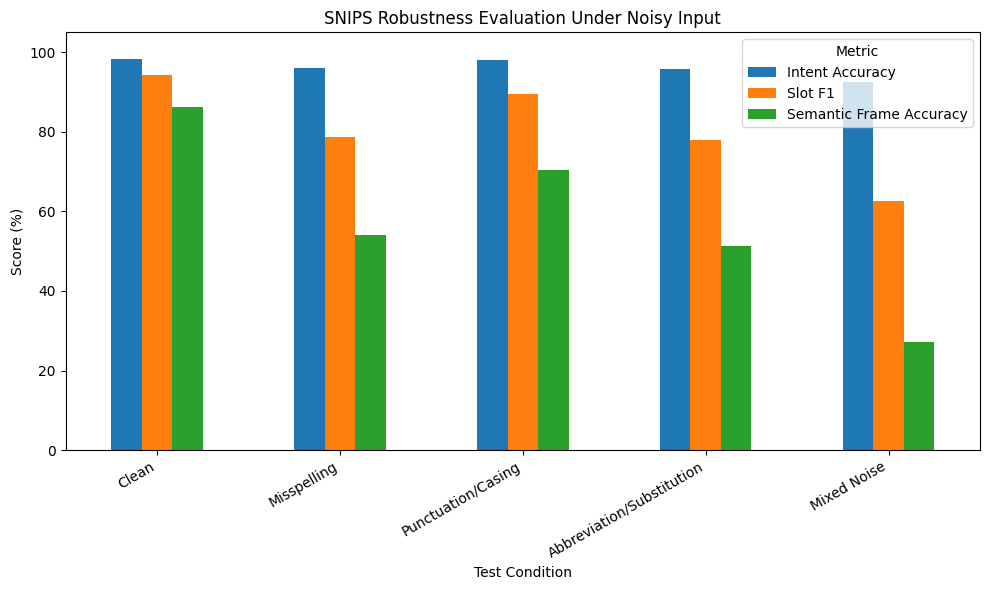

Saved graph as snips_noise_robustness_plot.png


In [ ]:
# Saving results table and creating graph

import matplotlib.pyplot as plt

percentage_df.to_csv("snips_noise_robustness_results.csv", index=False)

print("Saved results table as snips_noise_robustness_results.csv")

plot_df = percentage_df[[
    "Test condition",
    "Intent Accuracy",
    "Slot F1",
    "Semantic Frame Accuracy"
]]

ax = plot_df.set_index("Test condition").plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("SNIPS Robustness Evaluation Under Noisy Input")
plt.xlabel("Test Condition")
plt.ylabel("Score (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 105)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig("snips_noise_robustness_plot.png", dpi=300)
plt.show()

print("Saved graph as snips_noise_robustness_plot.png")